# Telco Customer Churn Prediction with CatBoost

## Project Overview

This notebook builds a machine learning model to predict customer churn using the Telco Customer Churn dataset. The goal is to identify customers who are likely to leave the company and understand the main factors that influence churn.

The project covers data cleaning, feature preprocessing, CatBoost model training, model evaluation, threshold tuning, feature importance, SHAP explainability, and business recommendations.

Customer churn prediction is useful for telecom companies because it helps detect high-risk customers early and design targeted retention strategies.


## Import Libraries

The required Python libraries are imported in this section. These libraries are used for data manipulation, visualization, model training, evaluation, and explainability.

Main tools used in this notebook include pandas, NumPy, matplotlib, scikit-learn, CatBoost, and SHAP.


In [1]:
!pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\reyha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder,LabelBinarizer,OneHotEncoder
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score, roc_curve
import time

## Install CatBoost

CatBoost is installed in the notebook environment. This step is needed only if CatBoost is not already available in the Python environment.


In [3]:
!pip install catboost


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\reyha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Import CatBoost

CatBoost classes are imported for model training, handling categorical features, and cross-validation.


In [4]:
from catboost import CatBoostClassifier,Pool,cv

## Load Dataset

The Telco Customer Churn dataset is loaded into a pandas DataFrame. The dataset contains customer demographic information, account details, service subscriptions, contract type, payment method, charges, tenure, and churn status.

The target variable is `Churn`, which shows whether a customer left the company or stayed.


In [5]:
df=pd.read_csv(r"C:\Users\reyha\Desktop\DATA SCIENCE CLASS ITALY\data science class\telco customer churn\WA_Fn-UseC_-Telco-Customer-Churn.csv")

## Data Cleaning and Preprocessing

In this section, the dataset is cleaned and prepared for machine learning. Missing values are handled, categorical variables are encoded, and numerical features are prepared for model training.

The target variable is `Churn`, where `1` means the customer churned and `0` means the customer stayed.

Cleaning the data is important because machine learning models require consistent numeric and categorical inputs.


### Handling Missing and Invalid Values

Blank strings are replaced with missing values so they can be handled consistently.

`TotalCharges` is also checked because it may contain blank or non-numeric values. Since `TotalCharges` represents the total amount charged to the customer, it must be converted into a numeric feature before model training.


In [6]:
df= df.replace(r'^\s*$', np.nan, regex=True)

### Handling `TotalCharges`

Customers with `tenure = 0` may have missing or blank `TotalCharges` because they are new customers. In this notebook, those values are set to `0`, then `TotalCharges` is converted into a numeric column.

This prevents errors during model training and keeps the feature meaningful.


In [7]:
if "tenure" in df.columns:  
    df.loc[df["tenure"] == 0, "TotalCharges"] = 0

In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])
print(df["TotalCharges"].dtype)

float64


## Feature Preparation

The dataset is separated into input features and the target variable.

The `customerID` column is removed because it is only an identifier and does not contain predictive information. The target variable `Churn` is converted into binary values: `No = 0` and `Yes = 1`.


In [9]:
#model
X=df.drop(columns=["customerID","Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})

## Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate how well the model performs on unseen data.

The split is stratified so that the churn and non-churn class proportions remain similar in both training and testing data.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

## Categorical Feature Identification

CatBoost can handle categorical variables directly when their column indices are provided.

In this section, categorical columns are detected automatically and their positions are stored. These indices are later passed to CatBoost during model training.


In [11]:

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


cat_indices = [X.columns.get_loc(c) for c in cat_cols]

print("Categorical columns:", cat_cols)
print("Their indices:", cat_indices)


Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Their indices: [0, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


## Model Training: CatBoost

CatBoost is trained as a supervised classification model to predict customer churn.

CatBoost is a gradient boosting algorithm that works well with structured tabular data and categorical variables. In this project, it learns patterns from customer information such as contract type, tenure, monthly charges, internet service, online security, tech support, and payment method.

Randomized search with cross-validation is used to test different hyperparameter combinations and select the model with the best ROC-AUC score.


In [12]:
cat_param = {
    "depth": [3, 5, 7],
    "learning_rate": [0.1, 0.01, 0.001],
    "iterations": [200, 400, 700],
    "l2_leaf_reg": [1, 3, 5],
}


cat = CatBoostClassifier(
     loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    allow_writing_files=False,
    verbose=0
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cat_model = RandomizedSearchCV(
    cat, cat_param, n_iter=15,
    scoring="roc_auc", cv=cv, n_jobs=-1, refit=True, random_state=42, verbose=2
)

t0 = time.time()
cat_model.fit(X, y, cat_features=cat_indices,
               early_stopping_rounds=100, verbose=100)
cat_time = time.time() - t0

print(f"Training time: {cat_time:.2f} seconds")
print("Best CV AUC:", cat_model.best_score_)
print("Best params:", cat_model.best_params_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
0:	total: 242ms	remaining: 2m 49s
100:	total: 8.24s	remaining: 48.9s
200:	total: 15.9s	remaining: 39.6s
300:	total: 23.5s	remaining: 31.2s
400:	total: 31.2s	remaining: 23.3s
500:	total: 40.2s	remaining: 16s
600:	total: 47.7s	remaining: 7.86s
699:	total: 55.1s	remaining: 0us
Training time: 636.40 seconds
Best CV AUC: 0.8481658195752203
Best params: {'learning_rate': 0.01, 'l2_leaf_reg': 3, 'iterations': 700, 'depth': 3}


## Cross-Validation Results

The cross-validation results show the tested hyperparameter combinations and their average validation performance.

This step helps compare model configurations and identify which CatBoost settings performed best during training.


In [13]:
results = pd.DataFrame(cat_model.cv_results_)
print(results[["params","mean_test_score","std_test_score","rank_test_score"]].head())

                                              params  mean_test_score  \
0  {'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iter...         0.846161   
1  {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iter...         0.848143   
2  {'learning_rate': 0.01, 'l2_leaf_reg': 3, 'ite...         0.848166   
3  {'learning_rate': 0.01, 'l2_leaf_reg': 3, 'ite...         0.843849   
4  {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iter...         0.843933   

   std_test_score  rank_test_score  
0        0.010934                7  
1        0.010491                2  
2        0.009300                1  
3        0.009140               12  
4        0.009186               11  


## Final Model Fitting

After hyperparameter tuning, the best CatBoost model is selected and trained again on the training set.

This final fitted model is then used to make predictions on the test set.


In [14]:
best_model = cat_model.best_estimator_
best_model.fit(X_train, y_train, cat_features=cat_indices, verbose=100)

0:	total: 59.3ms	remaining: 41.5s
100:	total: 7.2s	remaining: 42.7s
200:	total: 14.1s	remaining: 35.1s
300:	total: 20.9s	remaining: 27.8s
400:	total: 27.4s	remaining: 20.4s
500:	total: 34s	remaining: 13.5s
600:	total: 40.9s	remaining: 6.74s
699:	total: 47.5s	remaining: 0us


CatBoostClassifier(allow_writing_files=False, depth=3, eval_metric='AUC', iterations=700, l2_leaf_reg=3, learning_rate=0.01, loss_function='Logloss', random_seed=42, verbose=0)

## Model Prediction and Evaluation

The trained CatBoost model is used to predict customer churn on the test set.

The model is evaluated using accuracy, confusion matrix, precision, recall, and F1-score. Because churn prediction is an imbalanced classification problem, accuracy alone is not enough. Recall for churn customers is especially important because the business goal is to detect customers who are likely to leave.


In [15]:

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Confusion Matrix:\n{confusion}")
print(f"Classification Report:\n{report}")

Accuracy: 0.80
Confusion Matrix:
[[938  97]
 [179 195]]
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



### ROC Curve

The ROC curve shows the relationship between the true positive rate and false positive rate at different classification thresholds.

ROC-AUC measures how well the model separates churn customers from non-churn customers. A higher ROC-AUC means the model has stronger discrimination ability.


In [16]:
import matplotlib
import matplotlib.pyplot as plt

print(matplotlib.__version__)
print(matplotlib.__file__)

3.10.7
C:\Users\reyha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\__init__.py


Test ROC-AUC: 0.8452607920638612


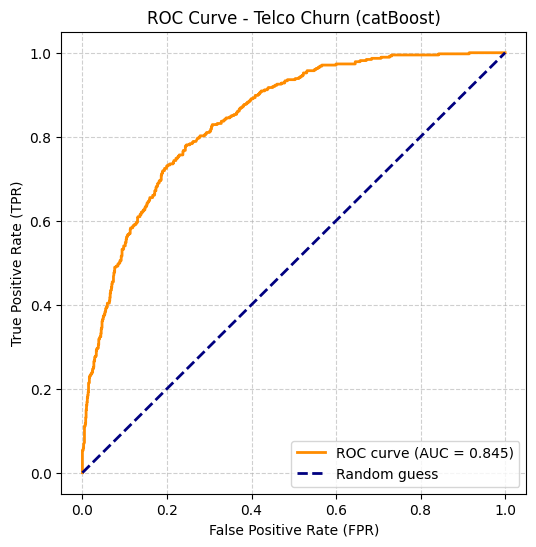

In [17]:
y_proba = best_model.predict_proba(X_test)[:, 1]  
auc = roc_auc_score(y_test, y_proba)
print("Test ROC-AUC:", auc)

fpr, tpr, thr = roc_curve(y_test, y_proba)


plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], color="navy", lw=2, linestyle="--", label="Random guess")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - Telco Churn (catBoost)")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### Precision-Recall Curve

The Precision-Recall curve is useful for imbalanced classification problems such as churn prediction.

Average Precision summarizes the trade-off between precision and recall. This metric is important because the churn class is smaller than the non-churn class.


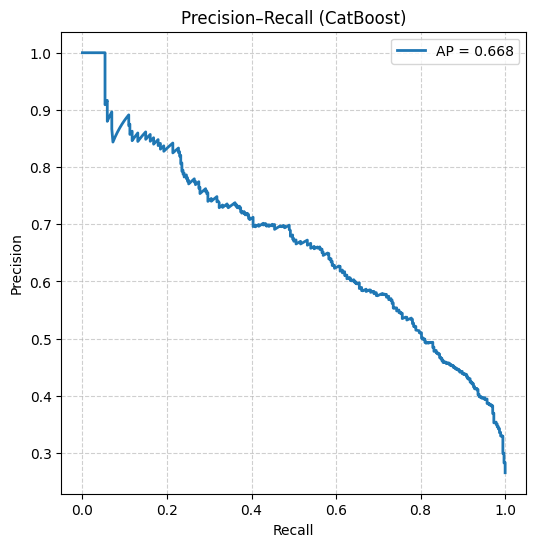

In [18]:
from sklearn.metrics import precision_recall_curve, average_precision_score
y_proba = best_model.predict_proba(X_test)[:,1]
ap = average_precision_score(y_test, y_proba)
p, r, th = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(r, p, lw=2, label=f'AP = {ap:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision–Recall (CatBoost)')
plt.legend(); plt.grid(True, ls='--', alpha=0.6); plt.show()


## Threshold Tuning

The default classification threshold is usually `0.5`, but this may not be the best choice for churn prediction.

In this section, the decision threshold is adjusted using the ROC curve and Youden's J statistic. A lower threshold can increase recall for churn customers, although it may also increase false positives.

This trade-off can be acceptable in many business cases because contacting some extra customers is usually less costly than missing customers who are likely to leave.


In [19]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report

from sklearn.metrics import roc_curve
fpr, tpr, thr = roc_curve(y_test, y_proba)
j_scores = tpr - fpr
t_opt = thr[j_scores.argmax()]  

y_pred = (y_proba >= t_opt).astype(int)
cm = confusion_matrix(y_test, y_pred)
print("Optimal threshold:", float(t_opt))
print(cm)
print(classification_report(y_test, y_pred, digits=3))

Optimal threshold: 0.2962104761341079
[[783 252]
 [ 83 291]]
              precision    recall  f1-score   support

           0      0.904     0.757     0.824      1035
           1      0.536     0.778     0.635       374

    accuracy                          0.762      1409
   macro avg      0.720     0.767     0.729      1409
weighted avg      0.806     0.762     0.774      1409



## Feature Importance

Feature importance is used to understand which variables contribute most to the CatBoost model predictions.

This section compares CatBoost feature importance with permutation importance. CatBoost importance shows which features the model uses most, while permutation importance measures how much model performance decreases when each feature is randomly shuffled.

Comparing both methods gives a more reliable view of which features are truly useful for churn prediction.


             Feature  CatBoost Importance  Permutation Importance
14          Contract            29.216800                0.055749
4             tenure            18.847815                0.042257
7    InternetService            11.566916                0.011044
11       TechSupport             8.858869                0.003668
17    MonthlyCharges             8.727601                0.003022
8     OnlineSecurity             6.598687                0.005350
18      TotalCharges             4.194233                0.005743
16     PaymentMethod             4.046545                0.003314
15  PaperlessBilling             2.164018                0.001644
9       OnlineBackup             1.935825                0.000262
6      MultipleLines             1.412176                0.001833
12       StreamingTV             0.651115               -0.000140
13   StreamingMovies             0.569315                0.000210
3         Dependents             0.383422                0.000130
1      Sen

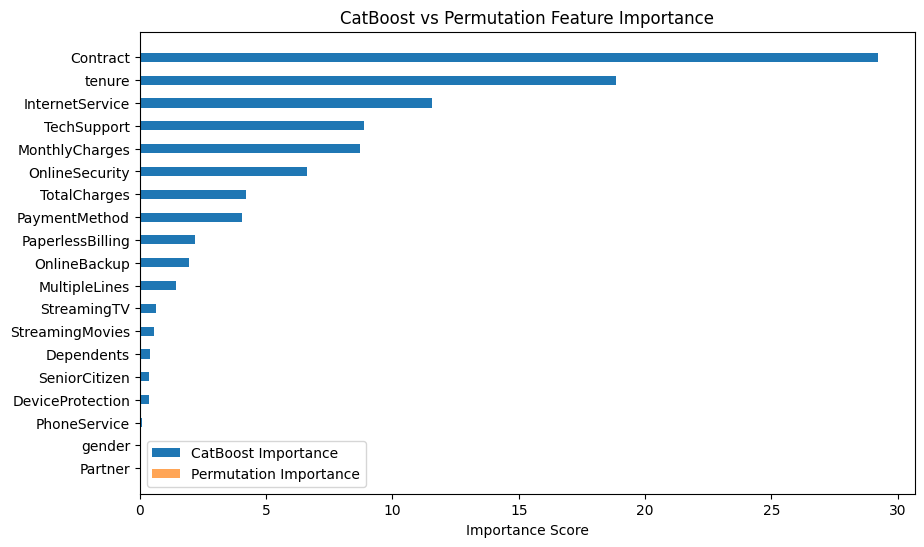

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance


cat_importance = best_model.get_feature_importance(type='PredictionValuesChange')
cat_df = pd.DataFrame({
    'Feature': X_test.columns,
    'CatBoost Importance': cat_importance
})


perm_result = permutation_importance(best_model, X_test, y_test,
                                     n_repeats=10,
                                     random_state=42,
                                     scoring='roc_auc')
perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Permutation Importance': perm_result.importances_mean
})


imp_df = pd.merge(cat_df, perm_df, on='Feature')
imp_df = imp_df.sort_values(by='CatBoost Importance', ascending=False)

print(imp_df)


fig, ax = plt.subplots(figsize=(10,6))
bar_width = 0.4
features = imp_df['Feature']


ax.barh(features, imp_df['CatBoost Importance'], 
        height=bar_width, label='CatBoost Importance')
ax.barh(features, imp_df['Permutation Importance'], 
        height=bar_width, label='Permutation Importance', alpha=0.7)

ax.set_xlabel("Importance Score")
ax.set_title("CatBoost vs Permutation Feature Importance")
ax.legend()
plt.gca().invert_yaxis()
plt.show()


## CatBoost Tree Visualization

This section visualizes one tree from the trained CatBoost model.

Tree visualization can help understand how the model makes some decision paths, although a full boosted model contains many trees and should not be interpreted from one tree alone.


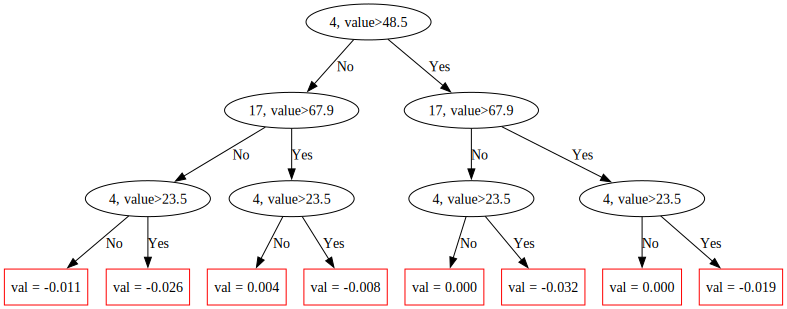

In [21]:
from catboost import CatBoostClassifier
tree_idx = 0
best_model.plot_tree(tree_idx)

## CatBoost Feature Importance Plot

This plot ranks features by their importance according to the trained CatBoost model.

The most important features help identify the main drivers of churn and connect the machine learning model to business interpretation.


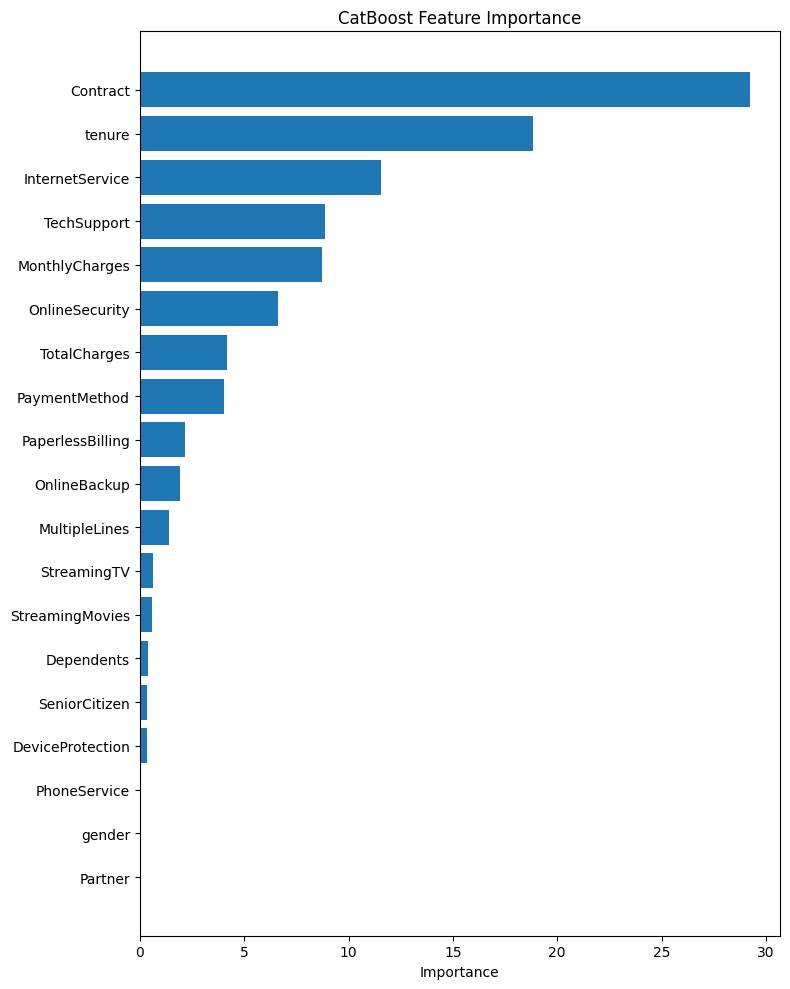

In [22]:
feature_names = list(X_train.columns)
fi = best_model.get_feature_importance()  

order = np.argsort(fi)
plt.figure(figsize=(8, 10))
plt.barh(np.array(feature_names)[order], np.array(fi)[order])
plt.title("CatBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## SHAP Explainability

SHAP is used to explain how features influence the model predictions.

Positive SHAP values increase the predicted probability of churn, while negative SHAP values decrease the predicted probability of churn.

This section includes a SHAP summary plot and dependence plots for important features such as `tenure` and `MonthlyCharges`. These plots help explain not only which features are important, but also how those features affect churn risk.

### SHAP Analysis: Tenure

The SHAP analysis for `tenure` shows how customer lifetime affects churn prediction. Customers with shorter tenure usually have higher churn risk, while customers with longer tenure tend to have lower churn risk. This suggests that new customers are more vulnerable and should be targeted with early retention actions.

### SHAP Analysis: Monthly Charges

The SHAP analysis for `MonthlyCharges` shows how monthly cost affects churn risk. Higher monthly charges can increase churn probability, especially when customers do not perceive enough value from the service.


In [24]:
import sys

!{sys.executable} -m pip install shap


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\reyha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 554.9/554.9 kB 4.6 MB/s  0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   - -------------------------------------- 1.6/41.9 MB 8.4 MB/s eta 0:00:05
   --- ------------------------------------ 3.4/41.9 MB 8.4 MB/s eta 0:00:05
   ---- ----------------------------------- 5.0/41.9 MB 8.4 MB/s eta 0:00:05
   ------ --------------------------------- 7.1/41.9 MB 8.6 MB/s eta 0:00:05
   -------- ------------------------------- 8.7/41.9 MB 8.4 MB/s eta 0:00:04
   ---------- ----------------------------- 10.5/41.9 MB 8.4 MB/s eta 0:00:04
   ----------- ---------------------------- 12.3/41.9 MB 8.5 MB/s eta 0:00:04
   ------------- -------------------------- 14.2/41.9 MB 8.5 MB/s eta 0:00:04
   --------------- ------------------------ 16.0

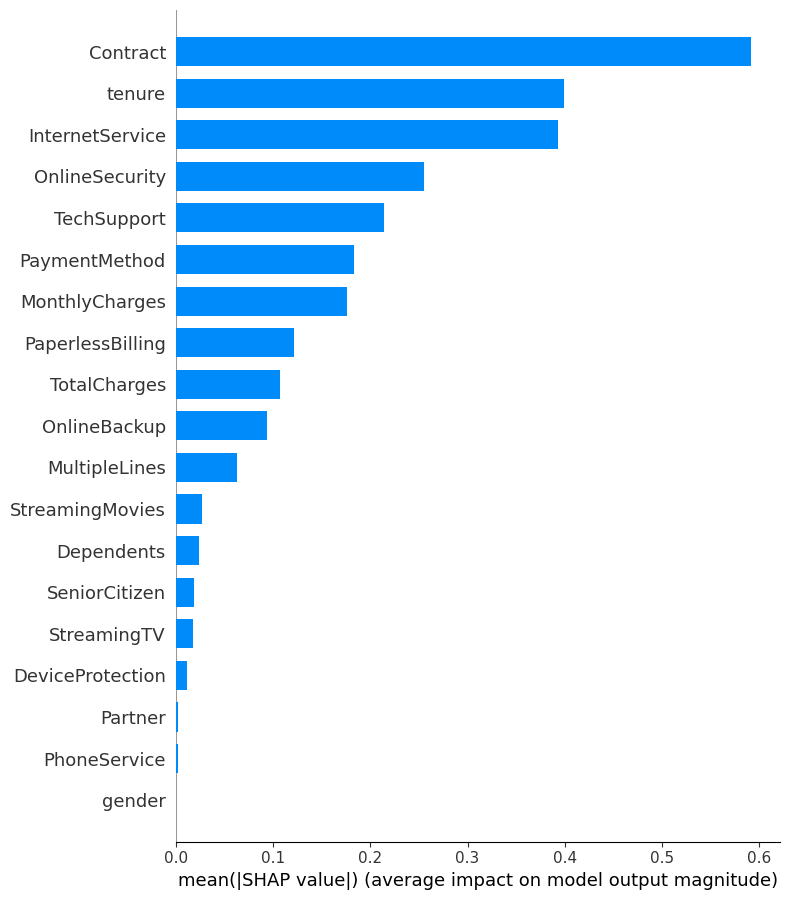

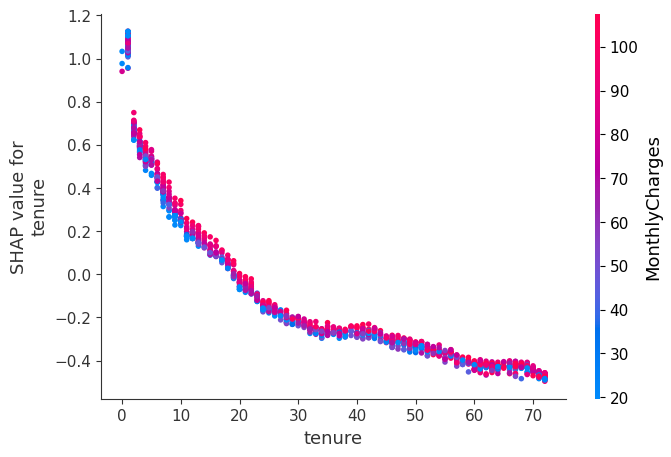

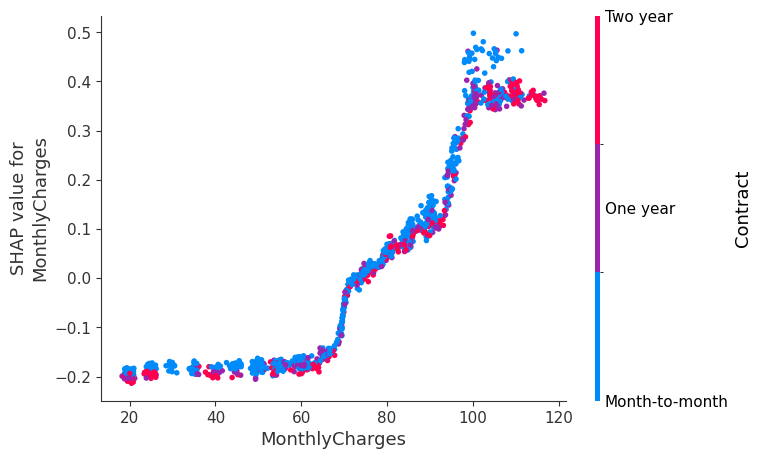

In [25]:
import shap



shap.initjs()


explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)


shap.summary_plot(shap_values, X_test, plot_type="bar")


i = 0
shap.force_plot(explainer.expected_value, shap_values[i, :], X_test.iloc[i, :])


shap.dependence_plot("tenure", shap_values, X_test)
shap.dependence_plot("MonthlyCharges", shap_values, X_test)

In [26]:
import os
os.makedirs("outputs", exist_ok=True)

In [27]:
predictions = pd.DataFrame({
    "customerID": df.loc[X_test.index, "customerID"],
    "actual_churn": y_test,
    "predicted_churn": y_pred,
    "churn_probability": y_proba
})

predictions.to_csv("outputs/catboost_predictions.csv", index=False)

predictions.head()

,customerID,actual_churn,predicted_churn,churn_probability
437,4376-KFVRS,0,0,0.065290
2280,2754-SDJRD,0,1,0.675222
2235,9917-KWRBE,0,0,0.058958
4460,0365-GXEZS,0,1,0.378707
3761,9385-NXKDA,0,0,0.036195


In [28]:
import os

print(os.getcwd())

c:\Users\reyha\Downloads


In [30]:


explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)


if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_test, show=False)

plt.tight_layout()
plt.savefig("outputs/catboost_shap_summary.png", dpi=300, bbox_inches="tight")
plt.close()

## Business Insights

The model results suggest that churn is strongly related to contract type, tenure, monthly charges, internet service, online security, tech support, total charges, and payment method.

Key insights:

1. Customers with month-to-month contracts are more likely to churn.
2. Customers with low tenure are at higher risk, especially during the early customer lifecycle.
3. Higher monthly charges can increase churn risk.
4. Customers without online security or tech support may be more likely to leave.
5. Contract type and customer tenure are among the strongest churn drivers.
6. Retention strategies should focus on customers with high predicted churn probability.

Possible business actions include offering contract upgrade incentives, targeted discounts, improved onboarding for new customers, better technical support, and personalized retention campaigns for high-risk customers.


## Conclusion

This notebook developed a CatBoost-based churn prediction model for the Telco Customer Churn dataset.

The model was trained, evaluated, and interpreted using feature importance and SHAP analysis. The results show that churn is mainly influenced by contract type, tenure, monthly charges, internet service, online security, tech support, and payment method.

From a business perspective, the model can help identify high-risk customers early and support targeted retention strategies.
